{'CVS': <class 'netCDF4.Variable'>
float64 CVS(Scalar)
    long_name: $Id: t4_mod_ncdf.F 964 2011-04-26 15:22:21Z evaleo $
    units: 
unlimited dimensions: Scalar
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'Raxis': <class 'netCDF4.Variable'>
float64 Raxis(Scalar)
    long_name: $R_{axis}$                               Major radius at the magnetic axis
    units: $cm$
unlimited dimensions: Scalar
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'xedg_in': <class 'netCDF4.Variable'>
float64 xedg_in(Scalar)
    long_name: $X_{in}$                                 Inner plasma edge on the equatorial pla
    units: $cm$
unlimited dimensions: Scalar
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'xedg_out': <class 'netCDF4.Variable'>
float64 xedg_out(Scalar)
    long_name: $X_{out}$                                Outer plasma edge on the equatorial pla
    units: $cm$
unlimited dimen

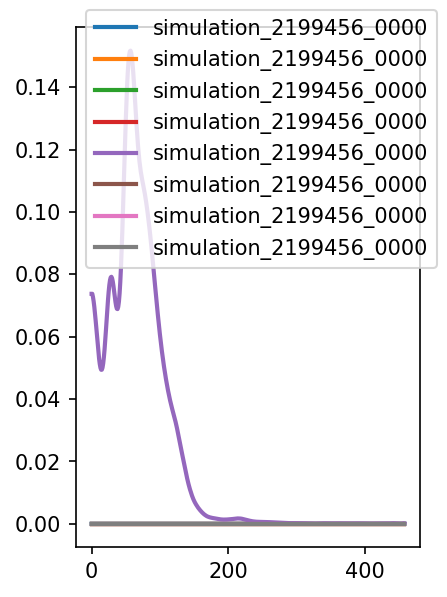

In [8]:
from netCDF4 import Dataset
from sys import argv
import os
import matplotlib.pyplot as plt

plot_var = 'ptcl_src'

fig, ax1 = plt.subplots(1,1,figsize = (3,4),dpi = 150)

# First just find the fastran.nc file ================
cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'
sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

for sim in sims:
    work_dir = SCAN_dir+'/'+sim+'/work'
    fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
    toric_dir = [f for f in os.listdir(work_dir) if f.startswith('rf_ic_toric')]
    ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
    tfile = work_dir+'/'+toric_dir[0]+'/toric.nc'
#=====================================================

    rootgrp = Dataset(tfile)

    #rho_tor = rootgrp['rho_tor'][:]
    power_ions_fund = rootgrp['PwIF'][:]

    print(rootgrp.variables)

    lw = 2
    c1 = 'green'
    c2 = 'lime'
    c3 = 'magenta'
    c4 = 'darkviolet'
    c5 = 'dodgerblue'
    c6 = 'cyan'
    
    ax1.plot(power_ions_fund, linewidth = lw, label = sim)

fig.tight_layout()
fig.legend()
plt.show()


In [ ]:
#print(rootgrp.variables)
plt.plot(rootgrp['sion'][-1,:])

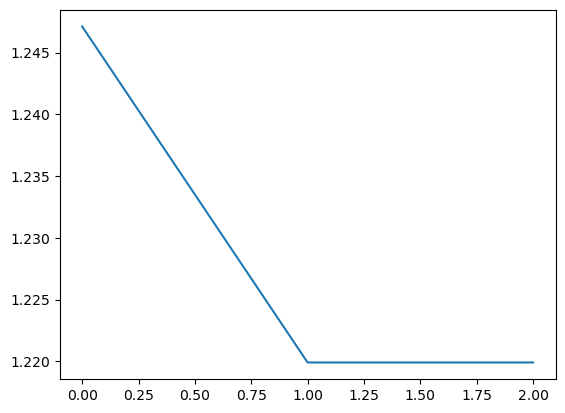